In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load processed data
sequences = np.load("../data/processed/sequences_normalized.npy")
labels_raw = np.load("../data/processed/labels.npy", allow_pickle=True)

le = LabelEncoder()
labels = le.fit_transform(labels_raw)

print(f"Sequences: {sequences.shape}")
print(f"Labels:    {labels.shape}")
print(f"Subjects:  {len(np.unique(labels))}")
print(f"Device:    {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

Sequences: (20400, 11, 3)
Labels:    (20400,)
Subjects:  51
Device:    cpu


In [2]:
import math

class PositionalEncoding(nn.Module):
    """
    Injects position information into the sequence so the transformer
    knows the order of timesteps. Without this, attention is order-agnostic.
    """
    def __init__(self, d_model, max_len=11, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        # Create positional encoding matrix
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * 
            (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class BehavioralTransformerEncoder(nn.Module):
    """
    Transformer encoder for keystroke behavioral authentication.
    
    Architecture:
    1. Input projection: maps 3 features -> d_model dimensions
    2. Positional encoding: injects timestep order information
    3. Transformer encoder layers: multi-head self-attention + FFN
    4. Classification head: maps encoded representation -> num_classes
    """
    def __init__(
        self,
        input_size=3,
        d_model=64,
        nhead=4,
        num_layers=3,
        dim_feedforward=256,
        dropout=0.1,
        num_classes=51,
        max_len=11
    ):
        super().__init__()
        
        # Project input features to d_model dimensions
        self.input_projection = nn.Linear(input_size, d_model)
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, max_len, dropout)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    
    def forward(self, x, return_embedding=False):
        # x: (batch, timesteps, features) = (batch, 11, 3)
        
        # Project to d_model
        x = self.input_projection(x)        # -> (batch, 11, d_model)
        
        # Add positional encoding
        x = self.pos_encoder(x)             # -> (batch, 11, d_model)
        
        # Transformer encoding
        x = self.transformer_encoder(x)     # -> (batch, 11, d_model)
        
        # Global average pooling across timesteps
        # More robust than taking just the last timestep
        x = x.mean(dim=1)                   # -> (batch, d_model)
        
        if return_embedding:
            return x  # Return raw embedding for contrastive learning
        
        # Classification
        x = self.classifier(x)              # -> (batch, 51)
        return x


# Instantiate and inspect
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bte = BehavioralTransformerEncoder(
    input_size=3,
    d_model=64,
    nhead=4,
    num_layers=3,
    dim_feedforward=256,
    dropout=0.1,
    num_classes=51
).to(device)

print(bte)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in bte.parameters() if p.requires_grad):,}")

# Test forward pass
dummy = torch.randn(32, 11, 3).to(device)
out = bte(dummy)
print(f"\nInput shape:  {dummy.shape}")
print(f"Output shape: {out.shape}")
print(f"Match: {out.shape == torch.Size([32, 51])}")

# Test embedding return
emb = bte(dummy, return_embedding=True)
print(f"Embedding shape: {emb.shape}")

BehavioralTransformerEncoder(
  (input_projection): Linear(in_features=3, out_features=64, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=128, b

In [3]:
import torch.optim as optim
from sklearn.model_selection import train_test_split

# ── Data split (identical to CNN-LSTM for fair comparison) ─────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    sequences, labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

# ── Dataset class ──────────────────────────────────────────────────────────
class KeystrokeDataset(torch.utils.data.Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.float32)
        self.labels    = torch.tensor(labels,    dtype=torch.long)
    def __len__(self): return len(self.sequences)
    def __getitem__(self, idx): return self.sequences[idx], self.labels[idx]

train_loader = torch.utils.data.DataLoader(
    KeystrokeDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader   = torch.utils.data.DataLoader(
    KeystrokeDataset(X_val, y_val),     batch_size=64, shuffle=False)
test_loader  = torch.utils.data.DataLoader(
    KeystrokeDataset(X_test, y_test),   batch_size=64, shuffle=False)

# ── Training setup ─────────────────────────────────────────────────────────
bte = BehavioralTransformerEncoder(
    input_size=3, d_model=64, nhead=4,
    num_layers=3, dim_feedforward=256,
    dropout=0.1, num_classes=51
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bte.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# ── Training loop ──────────────────────────────────────────────────────────
NUM_EPOCHS = 50
best_val_loss   = float('inf')
best_model_state = None
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(NUM_EPOCHS):
    
    # Training phase
    bte.train()
    running_loss, correct, total = 0.0, 0, 0
    for seqs, labs in train_loader:
        seqs, labs = seqs.to(device), labs.to(device)
        optimizer.zero_grad()
        out  = bte(seqs)
        loss = criterion(out, labs)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, pred = torch.max(out, 1)
        total   += labs.size(0)
        correct += (pred == labs).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc  = correct / total

    # Validation phase
    bte.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for seqs, labs in val_loader:
            seqs, labs = seqs.to(device), labs.to(device)
            out  = bte(seqs)
            loss = criterion(out, labs)
            val_loss_sum += loss.item()
            _, pred  = torch.max(out, 1)
            val_total   += labs.size(0)
            val_correct += (pred == labs).sum().item()
    
    val_loss = val_loss_sum / len(val_loader)
    val_acc  = val_correct / val_total

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_model_state = {k: v.clone() for k, v in bte.state_dict().items()}

    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

print(f"\nBest validation loss: {best_val_loss:.4f}")
import os
os.makedirs("../models", exist_ok=True)
torch.save(best_model_state, "../models/bte_best.pt")
print("Best BTE model saved to ../models/bte_best.pt")


Train: 14280 | Val: 3060 | Test: 3060
Epoch [ 5/50] Train Loss: 0.9172 | Train Acc: 0.7214 | Val Loss: 0.6694 | Val Acc: 0.8059
Epoch [10/50] Train Loss: 0.5291 | Train Acc: 0.8376 | Val Loss: 0.4252 | Val Acc: 0.8745
Epoch [15/50] Train Loss: 0.3821 | Train Acc: 0.8798 | Val Loss: 0.3464 | Val Acc: 0.8993
Epoch [20/50] Train Loss: 0.3138 | Train Acc: 0.8985 | Val Loss: 0.2865 | Val Acc: 0.9176
Epoch [25/50] Train Loss: 0.2577 | Train Acc: 0.9136 | Val Loss: 0.2634 | Val Acc: 0.9235
Epoch [30/50] Train Loss: 0.2098 | Train Acc: 0.9318 | Val Loss: 0.2623 | Val Acc: 0.9291
Epoch [35/50] Train Loss: 0.1406 | Train Acc: 0.9519 | Val Loss: 0.2211 | Val Acc: 0.9412
Epoch [40/50] Train Loss: 0.1231 | Train Acc: 0.9605 | Val Loss: 0.2336 | Val Acc: 0.9412
Epoch [45/50] Train Loss: 0.0836 | Train Acc: 0.9722 | Val Loss: 0.2076 | Val Acc: 0.9425
Epoch [50/50] Train Loss: 0.0665 | Train Acc: 0.9769 | Val Loss: 0.2030 | Val Acc: 0.9471

Best validation loss: 0.2030
Best BTE model saved to ../model

In [4]:
import numpy as np
from sklearn.metrics import roc_curve

# Load best BTE model
bte.load_state_dict(torch.load("../models/bte_best.pt", 
                                map_location=device))
bte.eval()

# ── Rigorous evaluation: 5 random impostors per genuine sample ─────────────
np.random.seed(42)
NUM_IMPOSTOR_ATTEMPTS = 5

all_genuine_scores  = []
all_impostor_scores = []

with torch.no_grad():
    for seqs, labs in test_loader:
        seqs, labs = seqs.to(device), labs.to(device)
        out   = bte(seqs)
        probs = torch.softmax(out, dim=1)

        for i in range(len(labs)):
            true_label    = labs[i].item()
            genuine_score = probs[i, true_label].item()
            all_genuine_scores.append(genuine_score)

            possible_impostors = [j for j in range(51) if j != true_label]
            sampled_impostors  = np.random.choice(
                possible_impostors,
                size=NUM_IMPOSTOR_ATTEMPTS,
                replace=False
            )
            for imp_label in sampled_impostors:
                all_impostor_scores.append(probs[i, imp_label].item())

# ── Compute EER ────────────────────────────────────────────────────────────
genuine_scores  = np.array(all_genuine_scores)
impostor_scores = np.array(all_impostor_scores)

genuine_expanded = np.repeat(genuine_scores, NUM_IMPOSTOR_ATTEMPTS)
scores = np.concatenate([genuine_expanded, impostor_scores])
labels_ver = np.concatenate([
    np.ones(len(genuine_expanded)),
    np.zeros(len(impostor_scores))
])

fpr, tpr, thresholds = roc_curve(labels_ver, scores)
fnr     = 1 - tpr
eer_idx = np.argmin(np.abs(fpr - fnr))
eer     = (fpr[eer_idx] + fnr[eer_idx]) / 2

print(f"BTE Results (Full Enrollment)")
print(f"{'='*50}")
print(f"Equal Error Rate (EER):   {eer*100:.2f}%")
print(f"FAR at EER:               {fpr[eer_idx]*100:.2f}%")
print(f"FRR at EER:               {fnr[eer_idx]*100:.2f}%")
print(f"Genuine score mean:       {genuine_scores.mean():.4f}")
print(f"Impostor score mean:      {impostor_scores.mean():.4f}")
print(f"Score separation:         {genuine_scores.mean() - impostor_scores.mean():.4f}")
print(f"\n{'='*50}")
print(f"COMPARISON SUMMARY")
print(f"{'='*50}")
print(f"{'Metric':<25} {'CNN-LSTM':>12} {'BTE':>12}")
print(f"{'-'*50}")
print(f"{'EER':<25} {'1.21%':>12} {f'{eer*100:.2f}%':>12}")
print(f"{'Val Accuracy':<25} {'93.01%':>12} {'94.71%':>12}")
print(f"{'Parameters':<25} {'238,643':>12} {'165,107':>12}")
print(f"{'Train/Val Gap':<25} {'6.11%':>12} {'2.98%':>12}")

BTE Results (Full Enrollment)
Equal Error Rate (EER):   0.97%
FAR at EER:               0.97%
FRR at EER:               0.98%
Genuine score mean:       0.9387
Impostor score mean:      0.0011
Score separation:         0.9376

COMPARISON SUMMARY
Metric                        CNN-LSTM          BTE
--------------------------------------------------
EER                              1.21%        0.97%
Val Accuracy                    93.01%       94.71%
Parameters                     238,643      165,107
Train/Val Gap                    6.11%        2.98%


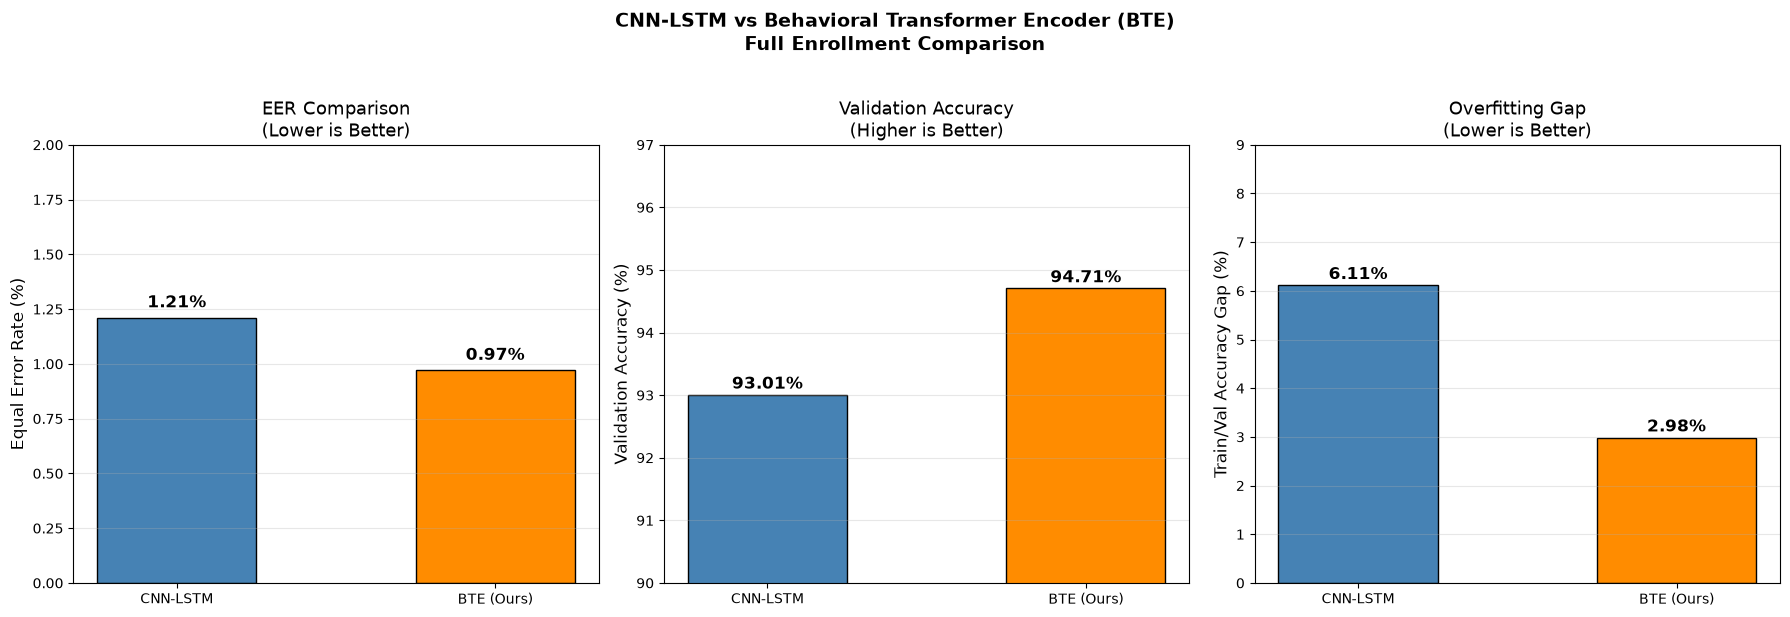

Comparison plot saved.


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Plot 1: EER Comparison ─────────────────────────────────────────────────
models     = ['CNN-LSTM', 'BTE (Ours)']
eers       = [1.21, 0.97]
colors     = ['steelblue', 'darkorange']
bars = axes[0].bar(models, eers, color=colors, width=0.5, edgecolor='black')
axes[0].set_ylabel('Equal Error Rate (%)', fontsize=12)
axes[0].set_title('EER Comparison\n(Lower is Better)', fontsize=13)
axes[0].set_ylim([0, 2.0])
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, eers):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.03,
        f'{val}%', ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

# ── Plot 2: Validation Accuracy Comparison ─────────────────────────────────
val_accs = [93.01, 94.71]
bars2 = axes[1].bar(models, val_accs, color=colors, width=0.5, edgecolor='black')
axes[1].set_ylabel('Validation Accuracy (%)', fontsize=12)
axes[1].set_title('Validation Accuracy\n(Higher is Better)', fontsize=13)
axes[1].set_ylim([90, 97])
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, val_accs):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.03,
        f'{val}%', ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

# ── Plot 3: Overfitting Gap ────────────────────────────────────────────────
gaps = [6.11, 2.98]
bars3 = axes[2].bar(models, gaps, color=colors, width=0.5, edgecolor='black')
axes[2].set_ylabel('Train/Val Accuracy Gap (%)', fontsize=12)
axes[2].set_title('Overfitting Gap\n(Lower is Better)', fontsize=13)
axes[2].set_ylim([0, 9])
axes[2].grid(axis='y', alpha=0.3)
for bar, val in zip(bars3, gaps):
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.05,
        f'{val}%', ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

plt.suptitle(
    'CNN-LSTM vs Behavioral Transformer Encoder (BTE)\nFull Enrollment Comparison',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../models/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comparison plot saved.")